## Import Libraries

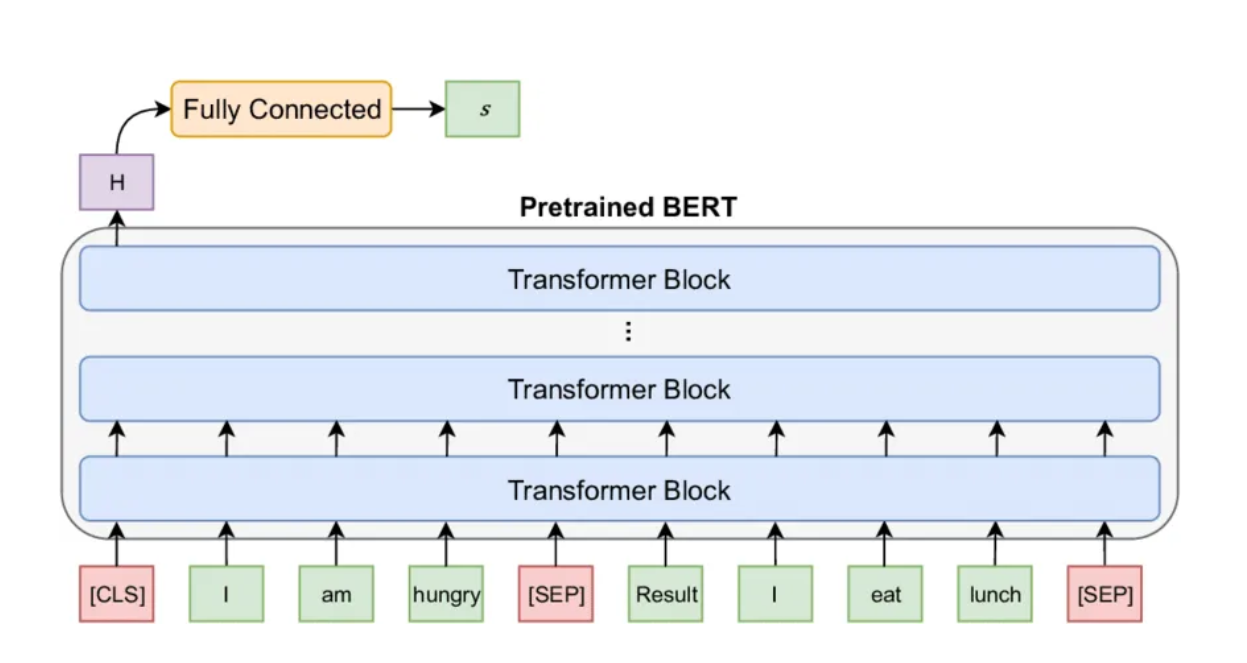
- https://medium.com/@pyroswolf200/fine-tuning-bert-on-imdb-review-dataset-309e90b6dac0

The IMDb Movie Reviews dataset is a binary sentiment analysis dataset consisting of 50,000 reviews from the Internet Movie Database (IMDb) labeled as positive or negative. In this article we will try to classify film review sentences as good or bad.

#### Without all the model, just loading from HG

In [70]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import  BertTokenizer ,BertModel
from tqdm import tqdm
from datasets import load_dataset

import random
import pandas as pd
from sklearn.model_selection import train_test_split
# from transformers import BertForSequenceClassification
# from transformers import AutoTokenizer
import matplotlib.pyplot as plt

In [74]:
import sys
sys.path.append('./src') #link to GTL libraries
import src.guided_transfer_learning as gtl

In [36]:
# Load pre-trained BERT model and adding a dense layer  
bert = BertModel.from_pretrained(
    'bert-base-uncased')
tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased')

################################################################
## Note:
# We can load BertForSequenceClassification, but when loadin we get the message: " Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']" ,so it is better to use this method
################################

# Define custom model architecture
class SentimentModel(nn.Module):
    def __init__(self, bert, num_labels, trainable=False):
        super().__init__()
        self.trainable = trainable
        self.bert = bert
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(bert.config.hidden_size, num_labels) # bert.config.hidden_size = 768

        # Set requires_grad=True for fine-tuning BERT
        if trainable == True:
            for param in self.bert.parameters():
                param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        output = self.dropout(pooled_output)
        logits = self.classifier(output)
        return logits
    
# Initialize model, loss_function, and optimizer
num_labels = 2
model = SentimentModel(bert, num_labels,trainable=True) 

# Move model to device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('Device: ', device)
model.to(device)

Device:  cpu


SentimentModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [37]:
# Load the IMDB dataset
dataset = load_dataset('imdb')

limit = 2 # Select only the first 'limit' samples from train and test sets for quick testing
train_dataset = dataset['train'].select(range(limit))
test_dataset = dataset['test'].select(range(limit))

In [38]:
# Define a preprocessing function to tokenize the text and encode it as input ids and attention masks
def preprocess_function(examples):
    # inputs = tokenizer(examples['text'], truncation=True, padding='max_length', return_tensors='pt')
    inputs = tokenizer(examples['text'], truncation=True, padding='max_length', max_length=64, add_special_tokens=True, return_attention_mask=True, return_tensors='pt')
    return {'input_ids': inputs['input_ids'].squeeze(), 'attention_mask': inputs['attention_mask'].squeeze(), 'labels': torch.tensor(examples['label'])}

In [39]:
# Preprocess the train and test datasets
train_dataset = train_dataset.map(preprocess_function, batched=True)
test_dataset = test_dataset.map(preprocess_function, batched=True)

In [40]:
# Convert datasets to torch Dataset
class CustomDatasetClass(Dataset):
    def __init__(self, dataset):
        self.input_ids = dataset['input_ids']
        self.attention_mask = dataset['attention_mask']
        self.labels = dataset['labels']

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.attention_mask[idx], dtype=torch.long),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = CustomDatasetClass(train_dataset)
test_dataset = CustomDatasetClass(test_dataset)

In [80]:
# Define the batch size and other data loader parameters
batch_size = 8
shuffle = True
num_workers = 0
epochs = 1

# Create data loaders for training and testing datasets
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# Define the optimizer and loss function
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_function = nn.CrossEntropyLoss()

# Define the training function
def train_model(model, optimizer, train_loader, loss_function, epochs, verbose=True, with_GTL=False, guidance_matrix=None):
    """
    Trains the model for a specified number of epochs.

    Args:
        model: The model to train.
        optimizer: The optimizer to use for training.
        train_loader: The data loader for the training dataset.
        loss_function: The loss function to use for training.
        epochs: The number of epochs to train for.
        verbose: Whether to print training progress.
        with_GTL: Whether to use guidance matrix for training.
        guidance_matrix: The guidance matrix to use for training.

    Returns:
        A list of the average loss for each epoch.
    """
    skip = 5000 if epochs > 10000 else 500 if epochs > 1000 else 50 if epochs > 100 else 5 if epochs > 10 else 1
    model.train() # Set the model to training mode
    loss_vals = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch in tqdm(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask)
            loss = loss_function(outputs, labels)
            model.zero_grad()
            loss.backward()
            if with_GTL and guidance_matrix is None:
                print('Guidance matrix is not provided')
                return None
            if with_GTL and guidance_matrix is not None:
                gtl.apply_guidance(model, guidance_matrix)
            optimizer.step()
            epoch_loss += loss.item()
        loss_vals.append(epoch_loss / len(train_loader))
        if verbose and ((epoch+1)%skip  == 0 or epoch == 0 or epoch == epochs-1):
            print(f'Epoch: {epoch} - Training loss: {epoch_loss / len(train_loader)}')
    return loss_vals

# Define the evaluation function
def evaluate_model(model, test_loader, loss_function):
    """
    Evaluates the model on the test dataset.

    Args:
        model: The model to evaluate.
        test_loader: The data loader for the test dataset.
        loss_function: The loss function to use for evaluation.

    Returns:
        The average loss and accuracy on the test dataset.
    """
    model.eval()  # Set the model to evaluation mode
    total_loss = 0
    total_acc = 0
    with torch.no_grad():
        for batch in tqdm(test_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask)
            loss = loss_function(outputs, labels)
            total_loss += loss.item()
            predictions = torch.argmax(outputs, dim=1)
            total_acc += (predictions == labels).sum().item()
    avg_loss = total_loss / len(test_loader)
    accuracy = total_acc / len(test_loader.dataset) * 100
    print(f'Test loss: {avg_loss} Test acc: {accuracy}%')
    return avg_loss, accuracy

# Define the plotting function
def plot_loss(numbers):
    """
    Plots a line graph of the given numbers against the epochs.
    Args:
    numbers (list): A list of numbers representing the loss values for each epoch.
    Returns:
    None: This function does not return any value. It only displays a plot.
    """
 
    plt.figure(figsize=(8, 5)) 
    plt.plot(range(1, len(numbers) + 1), numbers, marker='o', linestyle='-')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Plot of Numbers')
    plt.grid(True)
    plt.show()

In [81]:
train_losses = train_model(model, optimizer, train_loader, loss_function, epochs=3,with_GTL=False)
# evaluate_model(model, test_loader, loss_function)

100%|██████████| 1/1 [00:01<00:00,  1.01s/it]


Epoch: 0 - Training loss: 0.19674117863178253


100%|██████████| 1/1 [00:00<00:00,  1.74it/s]


Epoch: 1 - Training loss: 0.17281301319599152


100%|██████████| 1/1 [00:00<00:00,  1.93it/s]

Epoch: 2 - Training loss: 0.14009758830070496


In [82]:
avg_loss, accuracy = evaluate_model(model,test_loader,loss_function) 

100%|██████████| 1/1 [00:00<00:00,  8.14it/s]

Test loss: 0.1373136192560196 Test acc: 100.0%


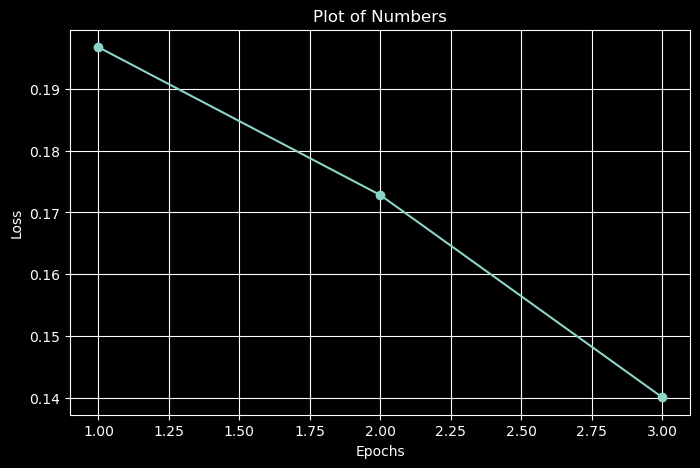

In [83]:
plot_loss(train_losses)

#### Get Dataset for training the Guidance matrix

In [45]:
from datasets import load_dataset

# Load the GoEmotions dataset
goemotions_dataset = load_dataset('go_emotions')

# Print dataset information
print(goemotions_dataset)


Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [69]:
# Get the number of samples in the dataset
num_samples = len(goemotions_dataset['train'])

# Select 1000 random indices

random_indices = random.sample(range(num_samples), 1000)

# Select random samples from the dataset
random_samples = [goemotions_dataset['train'][idx] for idx in random_indices]

# Create a new dataset with the selected random samples
random_dataset = Dataset.from_dict({'text': [sample['text'] for sample in random_samples],
                                    'labels': [sample['labels'] for sample in random_samples],
                                    'id': [sample['id'] for sample in random_samples]})

# Print the number of samples in the new dataset
print(f"Number of samples in the new dataset: {len(random_dataset)}")

# Print the first few samples from the new dataset
print(random_dataset[:10])  # Print first 10 samples

Number of samples in the new dataset: 1000
{'text': ['And oof for the red car', 'Can you imagine the [NAME] brothers getting pitched by a woman who believes in chemtrails', 'I find sativa makes me paranoid/anxious as hell. Indica calms me down more. Smoking too much of any strain makes me anxious by time though', 'Me too!!!', 'Now i need an island visit and a nice beef dip from the Crown and Gate!', 'Wait project players magically become great without showing any improvement who would have thought!!!', 'This is a joke, right...?', 'Well the three games is all we have to go off of, and he was bad.', '>more money than you I seriously, *seriously* doubt that. >doing something before this guys are outta the country Prove it.', 'Yep! Wanna come do karate in the garage?'], 'labels': [[23], [27], [19], [27], [8], [0, 20], [7], [9], [2], [27]], 'id': ['ee2r6ec', 'ef2lj8i', 'edbe4la', 'edulnum', 'ed306el', 'eeb0yzp', 'eer1wu2', 'ed5vcsi', 'eebwhv4', 'ee0xvq1']}


#### Guidance Matrix

In [ ]:
base_train_X = torch.tensor([[0.1, 0.1], [0.1, 1], [1, 0.1], [1, 1]]).to(device) 
base_train_Y = torch.tensor([[0.1, 0.1], [1, 0.1], [1, 0.1], [1, 1]]).to(device)

# We do not have separate test data for this problem.
base_test_X = base_train_X
base_test_Y = base_train_Y

base_scout_X = torch.tensor([[0.1, 0.1], [0.1, 1], [1, 0.1], [1, 1]]).to(device)
base_scout_Y = torch.tensor([[0.1, 0.1], [1, 1],   [1, 1],   [0.1, 0.1]]).to(device)



In [ ]:
# These are data for XOR functions from which we select scouts
base_scout_X = torch.tensor([[0.1, 0.1], [0.1, 1], [1, 0.1], [1, 1]]).to(device)
base_scout_Y = torch.tensor([[0.1, 0.1], [1, 1],   [1, 1],   [0.1, 0.1]]).to(device)

In [79]:
torch.manual_seed(3841574609) 

In [75]:
my_scouts = gtl.create_scouts(model) 

In [ ]:
# -------------------------------------------------------------------------------------------
# ------------------------ Create scout data from indexes -----------------------------------

# we use a GTL function create_scout_data_from_ranged_indexes() to create scouts of 
# the list of the data points in scout_indexes
scout_data_X = gtl.create_scout_data_from_ranged_indexes(scout_indexes, base_scout_X) # --using gtl library to create scout data
scout_data_Y = gtl.create_scout_data_from_ranged_indexes(scout_indexes, base_scout_Y) # --
print("There are", len(scout_data_X), "scouts")

In [ ]:

# -----------------------------------------------------------------------------------------------
# ----------------- Train scouts in a loop and accumulate data to obtain a guiding matrix ------------------------

# Now create a model for scouts and load parameters from the base model.
# These parameters are needed to continue learning from the based model. 
# Each scout is a fine-tuned version of the base model. 

model = model().to(device)
my_scouts = gtl.create_scouts(model)       # --------using gtl library to create my_scouts object to collect scout data

for s in range(len(scout_data_X)):
    print("scout number:", s)
    gtl.load_base(model)                  # ------------using gtl library to newly load base model for each scout
    train_model(model=model, x=scout_data_X[s], y=scout_data_Y[s], epochs=1000, lr=0.001)
    
    my_scouts.add_scout(model)            # ------------using gtl library to add scout data to the object
    
    
print("A total of", len(my_scouts), "scouts trained")



# ----------------------------------------------------------------------
# ----------------- Compute guidance matrix ----------------------------

guidance_matrix = my_scouts.create_raw_guidance(device) # ----------using gtl library to compute the guidance 
                                                                    # \matrix from accumulated scout information

                                                                    # \'device' determines whether to create the 
                                                                    # \guidance matrix on CPU or GPU.



# --------------------------------------------------------------
# ------------------- Save guidance matrix ---------------------

gtl.save_guidance_matrix(guidance_matrix)               # ----------using gtl library to save the guidance 
                                                                    # \matrix to default path and name

# ------------------------------------------------------------------------------------------
# ------------------------ Delete everything from memory -----------------------------------

# Release memory for scouts as we do not need them any more; guidance matrix can also be loaded anew
del my_scouts
del guidance_matrix



#Fine tuning with guidance matrix
guidance_matrix = gtl.load_guidance_matrix()     # -using gtl library----------
gtl.adjust_guidance_matrix(guidance_matrix, 'zero_enforced_and_normalized', 'warm')
gtl.scale_guidance_matrix(guidance_matrix, 2)    # -using gtl library----------


g_model = TinyModel().to(device)
gtl.load_base(g_model)                          # -----------using gtl library to load the base model

loss_vals_g = train_model(model=g_model, x=base_train_X2, y=base_train_Y2, epochs=299, guidance_matrix=guidance_matrix, lr = 0.01)



#### Train on 200 examples wihtou GTL:


In [78]:
## Testing:



#### Train on 200 examples wiht GTL:

In [ ]:
# Testing: 


#### Get Model Weights

#### Get Dataset

#### Fine Tune Without GTL

#### Test Results

#### Fine Tune With GTL

In [ ]:
# ------------------------------------------------------------------------------------------------
# ------------------------ Specify data points to use in each scout ------------------------------

# The data are breaking the large problem into smaller problems. 
# Two scouts are created, each with two data points.  

scout_indexes = [[1, 3], [2, 3]] #change tensors




# -------------------------------------------------------------------------------------------
# ------------------------ Create scout data from indexes -----------------------------------

# we use a GTL function create_scout_data_from_ranged_indexes() to create scouts of 
# the list of the data points in scout_indexes
scout_data_X = gtl.create_scout_data_from_ranged_indexes(scout_indexes, base_scout_X) # --using gtl library to create scout data
scout_data_Y = gtl.create_scout_data_from_ranged_indexes(scout_indexes, base_scout_Y) # --
print("There are", len(scout_data_X), "scouts")



# ----------------------------------------------------------------------------------------------------------------
# ----------------- Train scouts in a loop and accumulate data to obtain a guiding matrix ------------------------

# Now create a model for scouts and load parameters from the base model.
# These parameters are needed to continue learning from the based model. 
# Each scout is a fine-tuned version of the base model. 

s_model = TinyModel().to(device)
my_scouts = gtl.create_scouts(s_model)       # --------using gtl library to create my_scouts object to collect scout data

for s in range(len(scout_data_X)):
    print("scout number:", s)
    gtl.load_base(s_model)                  # ------------using gtl library to newly load base model for each scout
    train_model(model=s_model, x=scout_data_X[s], y=scout_data_Y[s], epochs=1000, lr=0.001)
    
    my_scouts.add_scout(s_model)            # ------------using gtl library to add scout data to the object
    
    
print("A total of", len(my_scouts), "scouts trained")



# ----------------------------------------------------------------------
# ----------------- Compute guidance matrix ----------------------------

guidance_matrix = my_scouts.create_raw_guidance(device) # ----------using gtl library to compute the guidance 
                                                                    # \matrix from accumulated scout information

                                                                    # \'device' determines whether to create the 
                                                                    # \guidance matrix on CPU or GPU.



# --------------------------------------------------------------
# ------------------- Save guidance matrix ---------------------

gtl.save_guidance_matrix(guidance_matrix)               # ----------using gtl library to save the guidance 
                                                                    # \matrix to default path and name

# ------------------------------------------------------------------------------------------
# ------------------------ Delete everything from memory -----------------------------------

# Release memory for scouts as we do not need them any more; guidance matrix can also be loaded anew
del my_scouts
del guidance_matrix



#Fine tuning with guidance matrix
guidance_matrix = gtl.load_guidance_matrix()     # -using gtl library----------
gtl.adjust_guidance_matrix(guidance_matrix, 'zero_enforced_and_normalized', 'warm')
gtl.scale_guidance_matrix(guidance_matrix, 2)    # -using gtl library----------


g_model = TinyModel().to(device)
gtl.load_base(g_model)                          # -----------using gtl library to load the base model

loss_vals_g = train_model(model=g_model, x=base_train_X2, y=base_train_Y2, epochs=299, guidance_matrix=guidance_matrix, lr = 0.01)



#### Test Results

## Testing